# Collecting data

In [1]:
# import module
import gwosc
from gwosc.datasets import event_gps, find_datasets
from gwpy.timeseries import TimeSeries
import gwpy
from pycbc.waveform import get_td_waveform
import pylab
from matplotlib import pyplot as plt
from gwpy.plot import Plot
from gwpy.signal import filter_design
import numpy as np
from gwosc.api import fetch_event_json
import h5py
from pycbc import inference

/home/val/anaconda3/lib/python3.12/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


In [187]:
# Event name
name_event = 'GW190517_055101'

# Get the GPS time for the event
gps = event_gps(name_event)

# segment of time to get around the GPS time
segment = (int(gps)-4, int(gps)+4)

In [188]:
# collect data online
try:
    hdata = TimeSeries.fetch_open_data('H1', *segment, cache=True)
except:
    hdata = None
    print('No data from H1')

try:
    ldata = TimeSeries.fetch_open_data('L1', *segment, cache=True)
except:
    ldata = None
    print('No data from L1')

try:
    vdata = TimeSeries.fetch_open_data('V1', *segment, cache=True)
except:
    vdata = None
    print('No data from V1')
try:
    gdata = TimeSeries.fetch_open_data('G1', *segment, cache=True)
except:
    gdata = None
    print('No data from G1')

No data from G1


In [189]:
available_data = []
detector = 0

# Check if each data array contains values and add it to the list if it does
try:
    if hdata[0] != 'nan':
        available_data.append(hdata)
        detector += 1
except:
    print('No data from H1')

try:
    if ldata[0] != 'nan':
        available_data.append(ldata)
        detector += 1 
except:
    print('No data from L1')

try:
    if vdata[0] != 'nan':
        available_data.append(vdata)
        detector += 1
except:
    print('No data from V1')
    
try:
    if gdata[0] != 'nan':
        available_data.append(gdata)
except:
    print('No data from G1')

No data from G1


# Collecting LIGO's estimate

In [190]:
# Find all datasets associated with the event name
datasets = find_datasets(type='event', detector=None, segment=segment)

# Find the newest dataset
if datasets:
    datasets.sort(reverse=True)  # Sort by string, to get newest first

    # Get the newest version of the event
    newest_event_name = datasets[0]

    # Get event parameters
    event_data = fetch_event_json(newest_event_name)

    # Extract distance and uncertainties from the event data
    distance = event_data['events'][newest_event_name].get('luminosity_distance')
    distance_lower = event_data['events'][newest_event_name].get('luminosity_distance_lower')
    distance_upper = event_data['events'][newest_event_name].get('luminosity_distance_upper')
    
    # Extract masses and uncertainties from event data
    mass1 = event_data['events'][newest_event_name].get('mass_1_source')
    mass1_lower = event_data['events'][newest_event_name].get('mass_1_source_lower')
    mass1_upper = event_data['events'][newest_event_name].get('mass_1_source_upper')
    
    mass2 = event_data['events'][newest_event_name].get('mass_2_source')
    mass2_lower = event_data['events'][newest_event_name].get('mass_2_source_lower')
    mass2_upper = event_data['events'][newest_event_name].get('mass_2_source_upper')

    if distance is not None:
        print(f"Distance to {newest_event_name}: {distance} Mpc")
        print(f"Uncertainty: {distance_lower} Mpc, +{distance_upper} Mpc")
        print('')
    else:
        print(f"No distance data available for {newest_event_name}")
        print('')
        
    if mass1 is not None:
        print(f"mass 1 of {newest_event_name}: {mass1} M_Sun")
        print(f"Uncertainty: {mass1_lower} M_Sun, +{mass1_upper} M_Sun")
        print('')
    else:
        print(f"No mass 1 data available for {newest_event_name}")
        print('')
        
    if mass2 is not None:
        print(f"mass 2 of {newest_event_name}: {mass2} M_Sun")
        print(f"Uncertainty: {mass2_lower} M_Sun, +{mass2_upper} M_Sun")
        print('')
    else:
        print(f"No mass 2 data available for {newest_event_name}")
        print('')
else:
    print(f"Could not find a dataset for event: {name_event}")

Distance to GW190517_055101-v2: 1790.0 Mpc
Uncertainty: -880.0 Mpc, +1750.0 Mpc

mass 1 of GW190517_055101-v2: 39.2 M_Sun
Uncertainty: -9.2 M_Sun, +13.9 M_Sun

mass 2 of GW190517_055101-v2: 24.0 M_Sun
Uncertainty: -7.9 M_Sun, +7.4 M_Sun



# Estimate low distance

In [191]:
from gwpy.timeseries import TimeSeries
from gwpy.astro import inspiral_range

D_range = []
D_range_high = []
    
for i in range(0,2):
    hoff = available_data[i].psd(fftlength=4)
    r1 = inspiral_range(hoff,fmin=20, fmax=1000, mass1=mass1, mass2=mass2)
    r2 = inspiral_range(hoff, mass1=mass1, mass2=mass2)

    SNR_threshold = 9
    SNR_measured = event_data['events'][newest_event_name].get('network_matched_filter_snr')
    D_range.append(r1 * SNR_threshold/SNR_measured)
    D_range_high.append(r2)

In [192]:
print(SNR_measured)

10.8


In [193]:
low_distance = np.mean([d.value for d in D_range])
high_distance = np.mean([d.value for d in D_range_high])
print(f"Low distance estimate:{low_distance} Mpc")
print(f"High distance estimate:{high_distance} Mpc")

Low distance estimate:1237.0974562749857 Mpc
High distance estimate:6617.798881276272 Mpc


# Collect data

In [194]:
# get a list of all the available parameters and urls for this event
strain_data = event_data['events'][newest_event_name].get('strain')
# List of detectors
detectors = ['G1', 'V1', 'H1', 'L1']

# Filter URLs for sampling rate 4096 and duration 32
filtered_urls = []
for file_info in strain_data:
    if file_info['sampling_rate'] == 4096 and file_info['duration'] == 32 and file_info['format'] == 'gwf':
        if any(detector in file_info['detector'] for detector in detectors):
            filtered_urls.append(file_info['url'])

In [195]:
# assign available urls to data
gdata = hdata = ldata = vdata = None
for url in filtered_urls:
    if "G-G1" in url:
        gdata = url
    elif "H-H1" in url:
        hdata = url
    elif "L-L1" in url:
        ldata = url
    elif "V-V1" in url:
        vdata = url

In [196]:
from pycbc.catalog import Merger
from pycbc.psd import interpolate, inverse_spectrum_truncation
from pycbc.frame import read_frame
from pycbc.filter import highpass, resample_to_delta_t
from astropy.utils.data import download_file

low_freq = 70

url_map = {'V1': vdata, 'G1': gdata, 'H1': hdata, 'L1': ldata}

# Initialise dictionaries for storing data
data_filenames = {}
psds = {}
data = {}

# Loop through each detector to get url
for detector in detectors:
    print(f"Processing {detector} data")
    
    # Get the url for available detector
    url = url_map.get(detector)
    
    # Check if url is None
    if url is None:
        print(f"No URL available for {detector}")
        continue

    # Download the file
    fname = download_file(url, cache=True)
    data_filenames[detector] = fname

    # Load the time series data for 4 seconds before and after the event
    ts = read_frame(fname, f"{detector}:GWOSC-4KHZ_R1_STRAIN",
                    start_time=int(gps - 4),
                    end_time=int(gps + 4))
    
    # Estimate and process the power spectral density (PSD)
    psd = ts.psd(4)
    psd = interpolate(psd, ts.delta_f)
    psd = inverse_spectrum_truncation(psd, int(4 * psd.sample_rate), 
                                      trunc_method='welch', 
                                      low_frequency_cutoff=low_freq)

    # Preprocess the data: high-pass filter, resample, and convert to frequency series
    ts = highpass(ts, low_freq) # Remove low-frequency content
    ts = resample_to_delta_t(ts, 1.0 / 2048)          # Resample to 2048 Hz
    data[detector] = ts          # Whiten the data

Processing G1 data
No URL available for G1
Processing V1 data
Processing H1 data
Processing L1 data


# Set up Inference

In [197]:
from pycbc.inference import models, sampler
from pycbc.distributions import Uniform, JointDistribution, SinAngle
import copy
from pycbc.inference.sampler import emcee_pt
approximant = 'IMRPhenomXPHM'


In [198]:
# configure model file
model_config = f"""
[model]
name = single_template
low-frequency-cutoff = 80
high-frequency-cutoff = 200
"""

!echo '{model_config}' > model.ini
!cat model.ini


[model]
name = single_template
low-frequency-cutoff = 80
high-frequency-cutoff = 200



In [199]:
# Get only detectors that have data
available_detectors = {detector: path for detector, path in data_filenames.items() if path}

# Prepare the instruments and frame-files strings based on available detectors
instruments = ' '.join(available_detectors.keys())
frame_files = ' '.join(f"{det}:{path}" for det, path in available_detectors.items())
channels = ' '.join(f"{det}:GWOSC-4KHZ_R1_STRAIN" for det in available_detectors.keys())

# Create the data configuration
data_config = f"""
[data]
instruments = {instruments}
trigger-time = {gps}
analysis-start-time = -4
analysis-end-time = 4
psd-estimation = median
psd-start-time = -4
psd-end-time = 4
psd-segment-length = 4
psd-segment-stride = 2
psd-inverse-length = 4
strain-high-pass = {low_freq}
sample-rate = 2048
frame-files = {frame_files}
channel-name = {channels}
"""

!echo '{data_config}' > data.ini
!cat data.ini


[data]
instruments = V1 H1 L1
trigger-time = 1242107479.8
analysis-start-time = -4
analysis-end-time = 4
psd-estimation = median
psd-start-time = -4
psd-end-time = 4
psd-segment-length = 4
psd-segment-stride = 2
psd-inverse-length = 4
strain-high-pass = 70
sample-rate = 2048
frame-files = V1:/home/val/.astropy/cache/download/url/9208c59e318c016bcbff51f2349177fa/contents H1:/home/val/.astropy/cache/download/url/504dce68ea1578b2a7f6ca5f097dba9a/contents L1:/home/val/.astropy/cache/download/url/38a774127f793baf33caa50e95723136/contents
channel-name = V1:GWOSC-4KHZ_R1_STRAIN H1:GWOSC-4KHZ_R1_STRAIN L1:GWOSC-4KHZ_R1_STRAIN



In [200]:
# create prior parameter file
prior_config = f"""
[variable_params]
distance =
inclination =
ra = 
dec =

[static_params]
mass1 = {mass1}
mass2 = {mass2}
f_lower = 20
approximant = {approximant}
polarization = 0
tc = {gps}

[prior-distance]
name = uniform
min-distance = {low_distance}
max-distance = {high_distance}

[prior-inclination]
name = sin_angle

[prior-ra+dec]
name = uniform_sky
"""
!echo '{prior_config}' > prior.ini
!cat prior.ini


[variable_params]
distance =
inclination =
ra = 
dec =

[static_params]
mass1 = 39.2
mass2 = 24.0
f_lower = 20
approximant = IMRPhenomXPHM
polarization = 0
tc = 1242107479.8

[prior-distance]
name = uniform
min-distance = 1237.0974562749857
max-distance = 6617.798881276272

[prior-inclination]
name = sin_angle

[prior-ra+dec]
name = uniform_sky



In [201]:
# create the sampler file
sampler_config = f"""
[sampler]
name = emcee_pt
ntemps=6
nwalkers=500
niterations=600
"""

!echo '{sampler_config}' > sampler.ini
!cat sampler.ini


[sampler]
name = emcee_pt
ntemps=6
nwalkers=500
niterations=600



# Do Inference

In [202]:
# run inference
!pycbc_inference --verbose \
    --config-files model.ini data.ini prior.ini sampler.ini \
    --output-file inference.hdf \
    --nprocesses 8 \
    --force    

2025-03-07T09:42:25.774+00:00 INFO : Using seed 0
2025-03-07T09:42:25.775+00:00 INFO : Running with CPU support: 1 threads
2025-03-07T09:42:25.775+00:00 INFO : Reading configuration file
2025-03-07T09:42:25.778+00:00 INFO : Setting up model
2025-03-07T09:42:25.782+00:00 INFO : Setting up priors for each parameter
2025-03-07T09:42:25.782+00:00 WARNING : No sampling_params section read from config file
2025-03-07T09:42:25.785+00:00 INFO : Determining analysis times to use
2025-03-07T09:42:25.785+00:00 INFO : Padding V1 analysis start and end times by 2 (= psd-inverse-length/2) seconds to account for PSD wrap around effects.
2025-03-07T09:42:25.785+00:00 INFO : Padding H1 analysis start and end times by 2 (= psd-inverse-length/2) seconds to account for PSD wrap around effects.
2025-03-07T09:42:25.786+00:00 INFO : Padding L1 analysis start and end times by 2 (= psd-inverse-length/2) seconds to account for PSD wrap around effects.
2025-03-07T09:42:25.786+00:00 INFO : Reading Frames
2025-03-

In [203]:
# plot a corner plot of the results from inference 
!pycbc_inference_plot_posterior --input-file inference.hdf \
    --output-file posterior.png \
    --plot-contours --plot-marginal \
    --plot-scatter --plot-marginal --z-arg snr

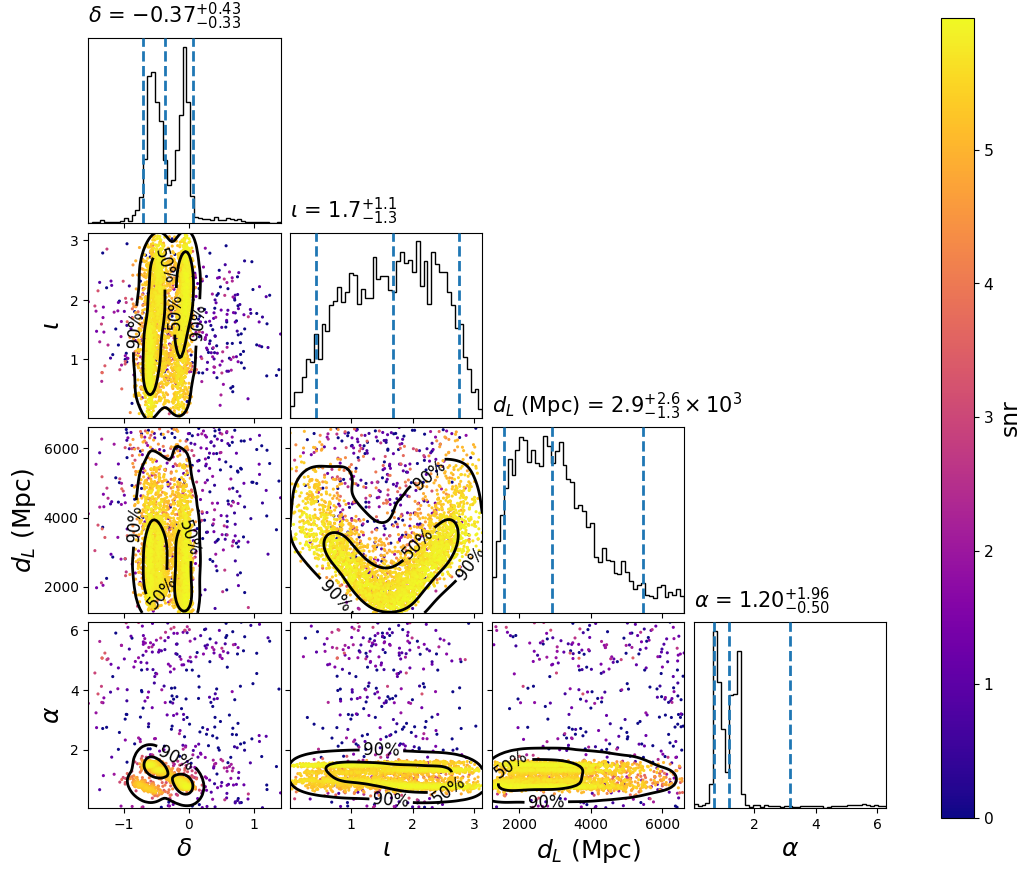

In [204]:
# plot the results for all posterior
from IPython.display import Image
Image('posterior.png', height=480)

In [209]:
# plot a density map of distance and inclination
!pycbc_inference_plot_posterior --input-file inference.hdf \
    --output-file posterior-dist_inc.png \
    --plot-density --plot-contours --plot-marginal \
    --parameters distance inclination 

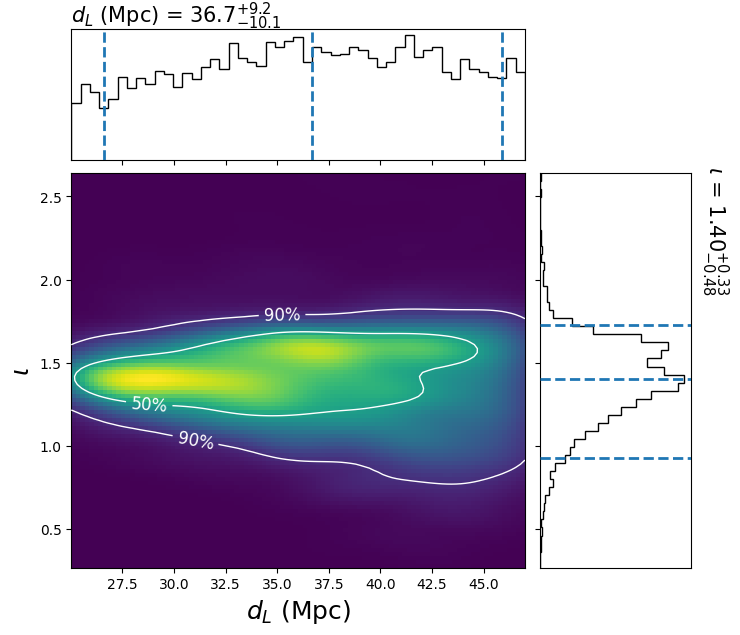

In [32]:
# Plot the result for distance and inclination
Image('posterior-dist_inc.png')